# Chapter 12 — Continuum Imaging with the VLA (CASA)

In **Chapter 8** we learned that an interferometer is a *Fourier machine*: each
baseline measures one visibility $V(u,v)$, and Earth rotation fills in the
$uv$-plane. In **Chapter 9** we took the resulting *dirty image* and ran
**Högbom's CLEAN (1974)** by hand to deconvolve the dirty beam back out. Those
chapters were small, single-frequency, in-memory NumPy demos — *just enough* to
understand the ideas.

This chapter is the **real-data sequel**. We move from a teaching toy to the
production pipeline that working radio astronomers actually use to turn raw
[**Karl G. Jansky Very Large Array**](https://public.nrao.edu/telescopes/vla/)
data into a science-quality image. The tool is
[**CASA**](https://casa.nrao.edu/) — the *Common Astronomy Software
Applications* package — and the data live in a **Measurement Set (MS)**.

> **Heads-up: this is a guarded chapter.** CASA's `casatasks`/`casatools`
> packages are large, pin specific Python versions, and pull in heavy binary
> dependencies — which is exactly why we keep them *out* of the base
> environment and in a dedicated container. So this notebook is written to
> **run end-to-end on the base environment** (where CASA is absent) by
> *demonstrating every concept with simulation*, while presenting the canonical
> CASA code as runnable-only-in-the-container cells gated behind a
> `CASA_AVAILABLE` flag. To actually execute the CASA cells, launch the
> container (instructions below).

### Learning goals

By the end of this chapter you will be able to:

- Explain **what a Measurement Set (MS) is** — the standardised table format
  that holds visibilities, $uv$-coordinates, antennas, spectral windows and
  flags for an interferometric observation.
- Walk the **real VLA continuum imaging workflow**: *inspect & flag* →
  *calibrate* (bandpass, gain, and flux-scale bootstrapping) → *image* with
  `tclean`.
- Connect `tclean` back to Chapter 9: it is the **production generalisation of
  Högbom CLEAN**, organised into **major and minor cycles**, with **visibility
  weighting** (natural / uniform / Briggs), **masks**, and **self-calibration**.
- **Read a resulting FITS image** with `astropy.io.fits` and
  `astropy.wcs.WCS`, and display it with the course helpers.

## The history: from CLEAN to CASA

Högbom's CLEAN (1974) made aperture-synthesis imaging *possible*; the decades
since made it *industrial*. Modern arrays — the VLA, ALMA, MeerKAT, and the SKA
to come — produce datasets far too large and too instrumentally complex to image
with a hand-written FFT loop. They need a calibration-and-imaging framework that
knows about polarization, wide bandwidths, primary beams, the $w$-term, and
self-calibration. That framework is **CASA**.

> **McMullin, J. P., Waters, B., Schiebel, D., Young, W. & Golap, K. (2007).**
> *CASA Architecture and Applications.* In *Astronomical Data Analysis Software
> and Systems XVI*, ASP Conf. Ser. **376**, 127.
> [ADS](https://ui.adsabs.harvard.edu/abs/2007ASPC..376..127M) — the original
> description of the CASA design that underpins VLA and ALMA data reduction.

> **CASA Team; Bean, B., Bhatnagar, S., Castro, S., et al. (2022).** *CASA, the
> Common Astronomy Software Applications for Radio Astronomy.* PASP **134**,
> 114501. [DOI](https://doi.org/10.1088/1538-3873/ac9642) — the modern,
> comprehensive reference paper; cite this one for current CASA.

The algorithm at the heart of CASA's imager is still recognisably Högbom's:

> **Högbom, J. A. (1974).** *Aperture Synthesis with a Non-Regular Distribution
> of Interferometer Baselines.* A&AS **15**, 417.
> [ADS](https://ui.adsabs.harvard.edu/abs/1974A%26AS...15..417H) — the CLEAN
> algorithm we implemented in Chapter 9.

To learn the *hands-on* workflow beyond this chapter, the canonical resources are
the **NRAO CASA Guides** — step-by-step tutorials on real VLA data:

- *VLA Continuum Tutorial — 3C391* (polarization & continuum imaging):
  <https://casaguides.nrao.edu/index.php/VLA_Continuum_Tutorial_3C391-CASA6.5.4>
- *VLA CASA Imaging* (the `tclean` deep-dive):
  <https://casaguides.nrao.edu/index.php/VLA_CASA_Imaging-CASA6.5.4>
- *Getting Started with the VLA* and the *VLA Calibration* guides:
  <https://casaguides.nrao.edu/index.php/Karl_G._Jansky_VLA_Tutorials>

This chapter follows the *shape* of those tutorials, with the heavy CASA steps
guarded so the notebook still runs without CASA installed.

## What a Measurement Set actually is

Chapter 8 wrote the visibility as a clean mathematical object,
$V(u,v) = \iint I(l,m)\,e^{-2\pi i (ul + vm)}\,\mathrm{d}l\,\mathrm{d}m$.
A real telescope never hands you $V(u,v)$ as a tidy array. It hands you a
**Measurement Set** — a directory of CASA *tables* (built on the `casacore`
table system) describing one observation in full.

The MS is, at heart, one giant **`MAIN` table** with one **row per visibility
sample**, plus a set of **sub-tables** holding the metadata those rows point
into. The columns that matter for imaging:

| Column / table | What it holds |
|---|---|
| `DATA` | the complex visibility $V$ for each row (raw correlator output) |
| `CORRECTED_DATA` | the calibrated visibilities (written by `applycal`) |
| `MODEL_DATA` | the model visibilities predicted from a sky model (used by self-cal) |
| `UVW` | the baseline coordinates $(u, v, w)$ **in metres** |
| `WEIGHT` / `SIGMA` | the statistical weight of each sample |
| `FLAG` | a boolean: is this sample bad (RFI, dead antenna, ...)? |
| `ANTENNA1`, `ANTENNA2` | which two antennas formed this baseline |
| `TIME`, `FIELD_ID`, `DATA_DESC_ID` | when, where on sky, which spectral window/pol |

and the sub-tables `ANTENNA`, `SPECTRAL_WINDOW`, `FIELD`, `POLARIZATION`,
`OBSERVATION`, ... give the array geometry, frequencies, source positions and so
on. The key mental model:

> A Measurement Set is a **relational database of visibilities**. Calibration is
> a sequence of operations that derive correction tables and *apply* them
> (`DATA` → `CORRECTED_DATA`); imaging is a Fourier inversion of the calibrated,
> weighted, unflagged visibilities followed by deconvolution.

Note the $w$ in `UVW`. Chapter 8's 2-D Fourier relation assumed a small,
flat field (the $w$-term negligible). Over a wide field of view the sky is *not*
flat and $w$ matters; CASA's `tclean` can handle this with **W-projection** or
**W-stacking** gridders. We will not need it for the small fields here, but it
is one of the things that separates a real imager from a textbook FFT.

## The VLA continuum workflow, end to end

A continuum imaging project, from raw MS to science image, is roughly:

1. **Inspect & flag.** Plot the data (`plotms`), find and remove bad data —
   radio-frequency interference (RFI), dead antennas, the noisy edges of each
   spectral window, shadowed antennas at the start/end of a scan
   (`flagdata`, `flagcmd`).
2. **Set the flux scale.** Tell CASA the absolute flux density of a primary
   *flux calibrator* (e.g. 3C286 / 3C48) from a standard model (`setjy`). This
   is the ruler that turns correlator counts into janskys.
3. **Calibrate.** Solve for the instrumental corruptions and apply them:
   - **Delay & bandpass** ($B$): the frequency-dependent complex gain of each
     antenna, solved on a bright bandpass calibrator (`bandpass`).
   - **Gain / phase** ($G$): the time-dependent complex gain, solved on a
     nearby gain calibrator observed periodically (`gaincal`).
   - **Flux-scale bootstrap**: transfer the absolute scale from the flux
     calibrator to the gain calibrator (`fluxscale`).
   - **Apply** all solution tables to the target (`applycal` → `CORRECTED_DATA`).
4. **Image.** Run `tclean` on the target's `CORRECTED_DATA` to make the dirty
   image, deconvolve it, and restore a clean image.
5. **(Optional) Self-calibrate.** Use the first image *as a model* to re-solve
   the antenna gains against the target itself, then re-image. Iterate. This is
   where faint structure and dynamic range come from.

The physics of step 3 is the **measurement equation**: the observed visibility
on baseline $(i,j)$ is the true visibility multiplied by per-antenna complex
gains (and convolved with the bandpass),

$$
V^{\mathrm{obs}}_{ij}(\nu, t) \;=\;
  g_i(t)\,g_j^{*}(t)\; b_i(\nu)\,b_j^{*}(\nu)\;
  V^{\mathrm{true}}_{ij}(\nu, t)\; +\; \text{noise}.
$$

Calibration is the business of estimating the $g_i(t)$ and $b_i(\nu)$ from
sources of *known* structure (calibrators), then dividing them out of the target.

## `tclean`: Högbom CLEAN, industrialised

Chapter 9's `hogbom_clean` did the whole deconvolution in the *image plane*:
find the peak, subtract a scaled dirty beam, repeat. That is fine for a 256×256
toy. For a real image it has two problems: the dirty beam is only
*approximately* shift-invariant across a wide field, and subtracting in the
image plane accumulates error. CASA's `tclean` solves both by splitting the work
into **major and minor cycles**:

- **Minor cycle** — *image plane.* A CLEAN-like deconvolver (Högbom,
  Clark, Cotton–Schwab, *multi-scale*, or *mtmfs* for wide bandwidth) finds and
  subtracts components against the (approximate) PSF, building up a sky model.
  This is exactly Chapter 9, run on the residual image.
- **Major cycle** — *visibility plane.* The current sky model is Fourier
  transformed back to model visibilities, *degridded*, subtracted from the data,
  and the **residual is re-imaged**. This re-introduces the exact instrumental
  response and corrects the approximation made in the minor cycle.

A few `tclean` parameters every VLA imager sets, and what they mean:

- **`weighting`** — how visibilities are weighted before the FFT. `'natural'`
  maximises point-source sensitivity (lowest noise) but gives a fat beam with
  strong sidelobes; `'uniform'` gives the sharpest beam at a noise cost; **Briggs**
  (`weighting='briggs'`, `robust` from $-2$ ≈ uniform to $+2$ ≈ natural) tunes
  smoothly between them. This is the practical control over the *dirty beam* you
  saw in Chapter 8.
- **`deconvolver`** — `'hogbom'`, `'clark'`, `'multiscale'` (for extended
  emission), or `'mtmfs'` (Multi-Term Multi-Frequency Synthesis, for the VLA's
  wide fractional bandwidth — models both flux and spectral index).
- **`niter`, `gain`, `threshold`** — the CLEAN loop budget: maximum minor-cycle
  components, loop gain (the same `gain` as Chapter 9), and the stopping flux.
- **`mask`** — restrict CLEAN to where you *know* there is emission, so it does
  not "clean" noise into the model. `usemask='auto-multithresh'` automates it.
- **`cell`, `imsize`** — the pixel scale and image size; choose `cell` to put
  ~3–5 pixels across the synthesised beam.

Self-calibration closes the loop with calibration: a good `tclean` model becomes
the input to another `gaincal`, tightening the gains and pushing up dynamic range.

## Setup

We import the base-environment stack (NumPy, Matplotlib, Astropy) and the
course helpers, then **probe for CASA**. On the base environment the import
fails and we set `CASA_AVAILABLE = False`; the notebook then runs entirely on
simulation. Inside the CASA container the import succeeds and the guarded cells
become live.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from jansky import interferometry, plotting
from jansky.interferometry import (
    uv_coverage, grid_visibilities, dirty_beam, dirty_image, hogbom_clean,
)
from jansky.plotting import use_jansky_style, show_image

use_jansky_style()
rng = np.random.default_rng(12)  # reproducible 'randomness' for this chapter

### Probe for CASA

CASA only runs in the dedicated container. We guard the import so the notebook
runs anywhere; the message tells you how to get the real thing.

In [2]:
# Guard the CASA import. On the base environment this WILL fail -- that is
# expected and fine; we fall back to simulation everywhere below.
try:
    import casatasks
    import casatools

    CASA_AVAILABLE = True
    print("CASA is available:", casatasks.version_string())
except ImportError:
    CASA_AVAILABLE = False
    print("CASA is NOT available in this environment (expected on the base env).")
    print()
    print("The CASA cells below are gated behind `CASA_AVAILABLE` and will be")
    print("skipped. To run them for real, launch the CASA container:")
    print()
    print("    podman compose -f containers/compose.yaml \\")
    print("        --profile interferometry up casa")
    print()
    print("then open this notebook from the JupyterLab it serves on port 8889.")

print("\nCASA_AVAILABLE =", CASA_AVAILABLE)

CASA is NOT available in this environment (expected on the base env).

The CASA cells below are gated behind `CASA_AVAILABLE` and will be
skipped. To run them for real, launch the CASA container:

    podman compose -f containers/compose.yaml \
        --profile interferometry up casa

then open this notebook from the JupyterLab it serves on port 8889.

CASA_AVAILABLE = False


## Step 1 — Inspect & flag (CASA)

The first thing you do with a fresh MS is *look at it*: how many antennas,
fields, and spectral windows? What is the integration time? Where is the RFI?
In CASA you would use `listobs` for a text summary, `plotms` for interactive
plots, and `flagdata` to excise bad data. The cell below is the canonical
incantation; it runs **only in the container**.

In [3]:
# --- CASA: inspect and flag an MS. Runs only inside the CASA container. ------
if CASA_AVAILABLE:
    from casatasks import listobs, flagdata

    vis = "data/3C391_ctm_mosaic_10s_spw0.ms"  # provided in the container's data/

    # A human-readable summary of the observation -> listobs.log
    listobs(vis=vis, listfile="listobs.log", overwrite=True)

    # Flag the obvious bad data:
    #   * antennas shadowed by their neighbours
    flagdata(vis=vis, mode="shadow", flagbackup=False)
    #   * zero-amplitude (dropped) visibilities
    flagdata(vis=vis, mode="clip", clipzeros=True, flagbackup=False)
    #   * the noisy edge channels of each spectral window (quack/edge flagging)
    flagdata(vis=vis, mode="quack", quackinterval=10.0, quackmode="beg",
             flagbackup=False)

    # A first-look summary of how much data is now flagged.
    summary = flagdata(vis=vis, mode="summary")
    print("Fraction flagged:", summary["flagged"] / summary["total"])
else:
    print("Skipped (CASA not available). See the simulated stand-in below.")

Skipped (CASA not available). See the simulated stand-in below.


### Concept stand-in (base env): the array, the $uv$-coverage, the dirty image

To *understand* what the MS holds without CASA, we rebuild the Chapter 8 picture
from first principles: a small VLA-like array, Earth-rotation $uv$-coverage, and
the dirty image of a model sky. Think of the arrays below as the contents of the
MS's `UVW`, `DATA`, and `FLAG` columns made tangible.

In [4]:
# A small VLA-like array: antennas spread over ~1 km (positions in metres).
# (The real VLA has 27 antennas on a Y; this is a teaching subset.)
antenna_xy = np.array([
    [   0.0,    0.0], [ 250.0,   40.0], [ -160.0,  230.0], [ 380.0, -200.0],
    [ -320.0, -110.0], [ 110.0,  430.0], [ -450.0, 270.0], [ 540.0,  160.0],
    [  90.0, -380.0], [ -210.0, -300.0],
])
n_ant = antenna_xy.shape[0]
print(f"{n_ant} antennas -> {n_ant * (n_ant - 1) // 2} baselines")

# Earth-rotation synthesis over +/- 4 h, source at dec +40 deg.
declination = np.deg2rad(40.0)
hour_angles = np.deg2rad(15.0 * np.linspace(-4.0, 4.0, 160))
uv = uv_coverage(antenna_xy, hour_angles=hour_angles, declination=declination)
print(f"{uv.shape[0]} uv samples (incl. conjugates) -- this is the MS's UVW column")

10 antennas -> 45 baselines
14400 uv samples (incl. conjugates) -- this is the MS's UVW column


In [5]:
npix = 256

def gaussian_blob(npix, row, col, amp, sigma):
    yy, xx = np.mgrid[0:npix, 0:npix]
    r2 = (yy - row) ** 2 + (xx - col) ** 2
    return amp * np.exp(-r2 / (2.0 * sigma ** 2))

# A model continuum field: a bright core + a jet-like extension + a faint blob.
sky = np.zeros((npix, npix))
sky[128, 120] = 1.0                                          # bright core
sky[132, 140] = 0.35                                         # knot down the 'jet'
sky[136, 160] = 0.18                                         # fainter knot
sky += gaussian_blob(npix, row=110, col=150, amp=0.25, sigma=5.0)  # diffuse lobe

# Grid the uv samples -> sampling mask S(u,v); form the dirty beam and image.
sampling = grid_visibilities(uv, npix=npix)
beam = dirty_beam(sampling)
dirty = dirty_image(sky, sampling)

# Add a little thermal noise, as a real (calibrated) MS would have.
dirty = dirty + rng.normal(scale=0.01, size=dirty.shape)

print("dirty image peak =", round(float(dirty.max()), 3))

dirty image peak = 0.108


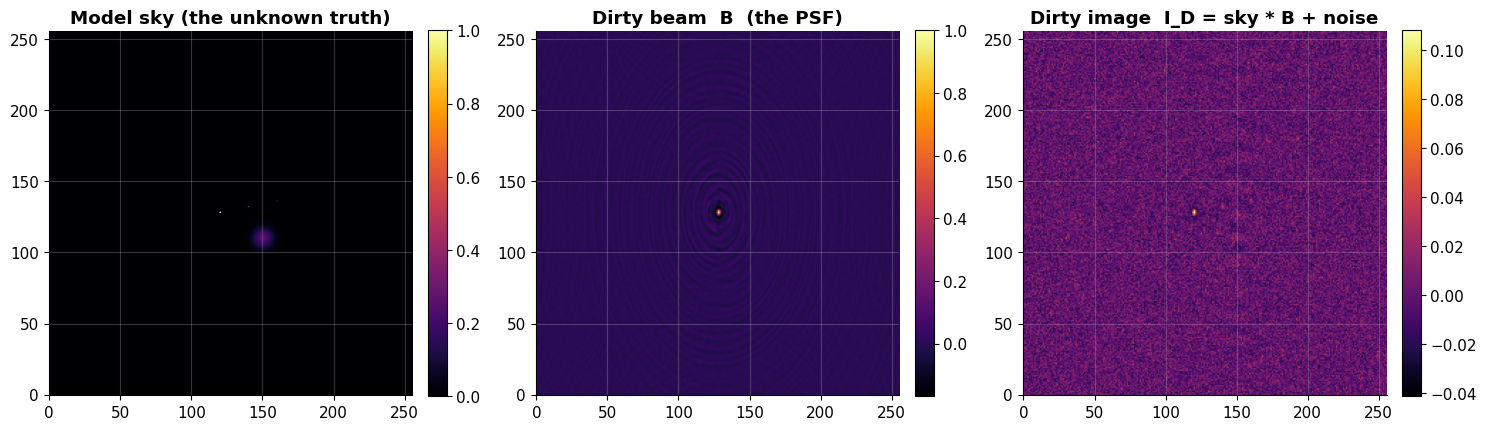

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
show_image(sky,   ax=axes[0], title="Model sky (the unknown truth)")
show_image(beam,  ax=axes[1], title="Dirty beam  B  (the PSF)")
show_image(dirty, ax=axes[2], title="Dirty image  I_D = sky * B + noise")
plt.tight_layout()
plt.show()

### The real thing: genuine VLA visibilities via `pyuvdata`

The arrays above were *simulated*. Here we open a **real** Measurement Set —
served as a single UVFITS file, so no `casacore` table directory (and no CASA) is
needed — with [`pyuvdata`](https://pyuvdata.readthedocs.io/) (the optional
`formats` extra). It is the **CASA-guides VLA continuum dataset**
(`day2_TDEM0003`): an (E)VLA observation of the calibrator **J1008+0730** at
~36 GHz. `pyuvdata` exposes exactly the MS columns described above —
`uvw_array` (the `UVW` column), `data_array` (the `DATA` column), `freq_array`,
`polarization_array`. We plot the genuine **uv-coverage** (the real `UVW`
sampling) and the **visibility amplitude versus baseline length**: for a
calibrator — a point source — that amplitude is roughly **flat** with baseline,
the very property `setjy`/`gaincal` rely on to fix the flux scale and gains.


EVLA: 18 antennas, 153 baselines, 15 times, 64 channels @ 36.3 GHz
source J1008+0730; uv-distance 5-123 klambda


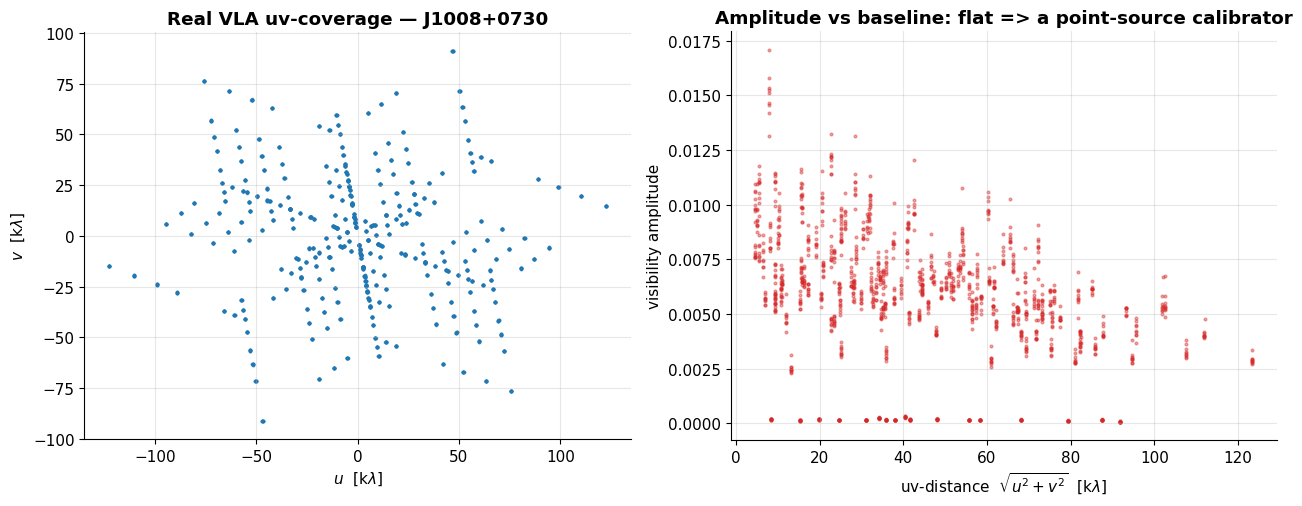

In [7]:
# Genuine VLA visibilities from a real UVFITS, read with pyuvdata -- the actual
# UVW / DATA columns of a Measurement Set, no CASA container needed. Guarded
# behind the `formats` extra + a one-time ~4 MB download.
try:
    from pyuvdata import UVData

    from jansky import data

    uvd = UVData()
    uvd.read(str(data.fetch("vla-uvfits")))
    src = next(iter(uvd.phase_center_catalog.values()))["cat_name"]
    nu = float(uvd.freq_array.flatten().mean())
    wav = 299792458.0 / nu  # wavelength [m]

    # UVW is stored in metres; divide by wavelength for u, v in kilo-lambda.
    uu = uvd.uvw_array[:, 0] / wav / 1e3
    vv = uvd.uvw_array[:, 1] / wav / 1e3
    uvdist = np.hypot(uu, vv)
    # Amplitude over the parallel-hand polarisations, band-averaged per baseline.
    par = np.isin(uvd.polarization_array, [-1, -2, -5, -6])  # RR/LL or XX/YY
    amp = np.abs(uvd.data_array[:, :, par]).reshape(uvd.Nblts, -1).mean(axis=1)

    print(f"{uvd.telescope.name}: {uvd.Nants_data} antennas, {uvd.Nbls} baselines, "
          f"{uvd.Ntimes} times, {uvd.Nfreqs} channels @ {nu / 1e9:.1f} GHz")
    print(f"source {src}; uv-distance {uvdist.min():.0f}-{uvdist.max():.0f} klambda")

    fig, (axuv, axamp) = plt.subplots(1, 2, figsize=(13, 5.2))
    axuv.scatter(uu, vv, s=3, color="#1f77b4", alpha=0.5)
    axuv.scatter(-uu, -vv, s=3, color="#1f77b4", alpha=0.5)  # Hermitian conjugates
    axuv.set_xlabel(r"$u$  [k$\lambda$]")
    axuv.set_ylabel(r"$v$  [k$\lambda$]")
    axuv.set_title(f"Real VLA uv-coverage — {src}")
    axuv.set_aspect("equal")

    axamp.scatter(uvdist, amp, s=4, color="#d62728", alpha=0.4)
    axamp.set_xlabel(r"uv-distance  $\sqrt{u^2+v^2}$  [k$\lambda$]")
    axamp.set_ylabel("visibility amplitude")
    axamp.set_title("Amplitude vs baseline: flat => a point-source calibrator")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"(Real VLA visibilities skipped: {type(exc).__name__}: {exc})")
    print("Install the `formats` extra (`uv sync --extra formats`) and re-run "
          "(needs a one-time ~4 MB download).")


## Step 2–3 — Set the flux scale and calibrate (CASA)

With the data flagged, we derive the calibration tables. The canonical VLA
sequence: `setjy` fixes the absolute flux scale on a standard calibrator;
`bandpass` solves the frequency response; `gaincal` solves the time-dependent
complex gain; `fluxscale` bootstraps the absolute scale onto the gain
calibrator; `applycal` writes `CORRECTED_DATA`. This whole block is
container-only.

In [8]:
# --- CASA: a canonical VLA calibration chain. Runs only in the container. ----
if CASA_AVAILABLE:
    from casatasks import setjy, bandpass, gaincal, fluxscale, applycal

    vis = "data/3C391_ctm_mosaic_10s_spw0.ms"
    flux_cal = "J1331+3030"   # 3C286, the absolute flux-density standard
    band_cal = flux_cal       # often the same bright source serves as bandpass cal
    gain_cal = "J1822-0938"   # nearby gain/phase calibrator
    target = "3C391*"         # the science field(s)

    # 1) Absolute flux scale from a standard model (Perley-Butler 2017).
    setjy(vis=vis, field=flux_cal, standard="Perley-Butler 2017",
          usescratch=True)

    # 2) Bandpass: the per-antenna frequency response B_i(nu).
    #    (A short-timescale phase-up gaincal usually precedes this; omitted here
    #     for brevity -- see the NRAO 3C391 CASA Guide for the full chain.)
    bandpass(vis=vis, caltable="cal.B0", field=band_cal,
             solint="inf", refant="ea21", solnorm=True)

    # 3) Gain/phase: the per-antenna time-dependent complex gain g_i(t).
    gaincal(vis=vis, caltable="cal.G0", field=f"{flux_cal},{gain_cal}",
            solint="int", refant="ea21", calmode="ap",
            gaintable=["cal.B0"])

    # 4) Bootstrap the absolute flux scale onto the gain calibrator.
    fluxscale(vis=vis, caltable="cal.G0", fluxtable="cal.G0.flux",
              reference=[flux_cal], transfer=[gain_cal])

    # 5) Apply everything to the target -> CORRECTED_DATA.
    applycal(vis=vis, field=target,
             gaintable=["cal.B0", "cal.G0.flux"],
             gainfield=[band_cal, gain_cal], interp=["nearest", "linear"])

    print("Calibration applied; CORRECTED_DATA is ready to image.")
else:
    print("Skipped (CASA not available). Calibration is assumed 'done' for the")
    print("simulated dirty image above -- our visibilities carry no instrumental")
    print("gains, so the dirty image already corresponds to CORRECTED_DATA.")

Skipped (CASA not available). Calibration is assumed 'done' for the
simulated dirty image above -- our visibilities carry no instrumental
gains, so the dirty image already corresponds to CORRECTED_DATA.


## Step 4 — Image with `tclean` (CASA)

Here is the production imaging call. Read it against the parameter glossary
above: Briggs weighting for a good resolution/sensitivity trade-off, the
multi-scale + multi-frequency deconvolver (`mtmfs`) the VLA's wide bandwidth
demands, an automatic mask, and a CLEAN budget (`niter`, `gain`, `threshold`).
This is the *exact* generalisation of Chapter 9's loop. Container-only.

In [9]:
# --- CASA: the canonical tclean call. Runs only in the container. -----------
if CASA_AVAILABLE:
    from casatasks import tclean, exportfits

    vis = "data/3C391_ctm_mosaic_10s_spw0.ms"
    imagename = "3C391_continuum"

    tclean(
        vis=vis,
        field="3C391*",
        imagename=imagename,
        # --- image geometry ---
        imsize=[480, 480],
        cell="2.5arcsec",            # ~5 px across the synthesised beam
        # --- gridding & weighting (Chapter 8's dirty-beam control) ---
        gridder="standard",          # 'wproject'/'mosaic' for wide/mosaic fields
        weighting="briggs",
        robust=0.5,                  # -2 ~ uniform ... +2 ~ natural
        # --- deconvolution (Chapter 9, industrialised) ---
        deconvolver="mtmfs",         # multi-term MFS: models flux + spectral index
        nterms=2,
        scales=[0, 5, 15],           # multi-scale: point + extended emission
        # --- the CLEAN loop budget ---
        niter=10000,                 # max minor-cycle components
        gain=0.1,                    # loop gain -- the SAME gain as hogbom_clean
        threshold="0.1mJy",          # stop when the peak residual reaches this
        # --- masking: don't clean noise into the model ---
        usemask="auto-multithresh",
        # major/minor cycles handled internally; this is the key abstraction.
        interactive=False,
        pbcor=True,                  # primary-beam correct the final image
    )

    # Export the restored image to FITS for analysis with astropy.
    exportfits(imagename=f"{imagename}.image.tt0",
               fitsimage=f"{imagename}.image.fits", overwrite=True)
    print("tclean finished; wrote", f"{imagename}.image.fits")
else:
    print("Skipped (CASA not available). The Hogbom stand-in below reproduces")
    print("the *minor cycle* of tclean on our simulated dirty image.")

Skipped (CASA not available). The Hogbom stand-in below reproduces
the *minor cycle* of tclean on our simulated dirty image.


### Concept stand-in (base env): the minor cycle is Chapter 9's CLEAN

`tclean`'s minor cycle *is* Högbom CLEAN. We can demonstrate it directly with
the Chapter 9 helper `interferometry.hogbom_clean`, running on the simulated
dirty image and dirty beam from above. The "restored" image — components
convolved with a clean beam, plus the residual — is exactly what `tclean`'s
`.image` product is.

CLEAN found 289 components
residual peak = 0.0300 (dirty peak was 0.1079)


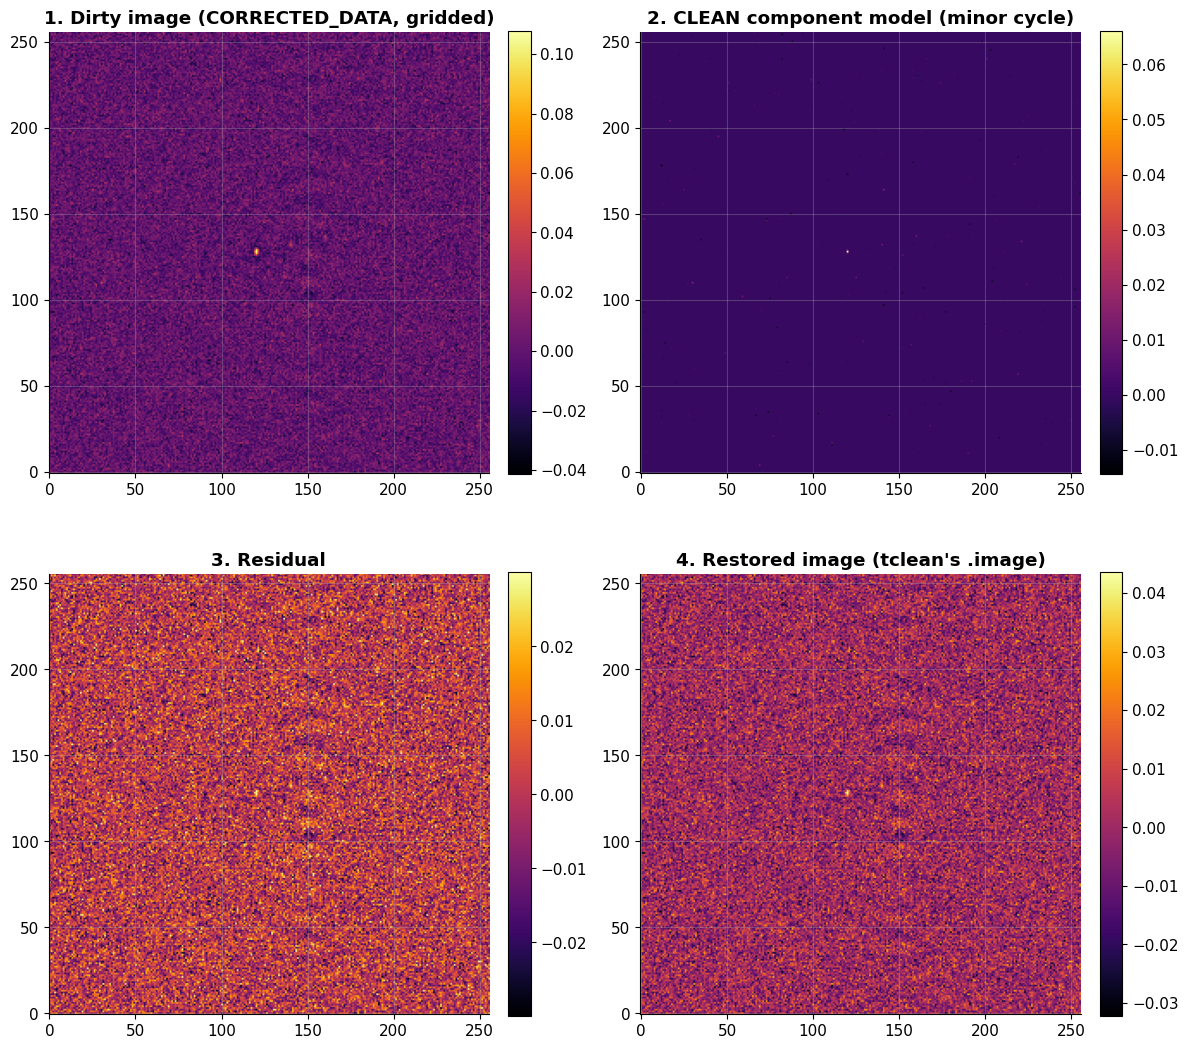

In [10]:
from scipy.ndimage import gaussian_filter

# Run the Chapter 9 minor cycle: find peak, subtract a scaled beam, repeat.
result = hogbom_clean(dirty, beam, gain=0.1, n_iter=2000, threshold=0.03)
print(f"CLEAN found {len(result.components)} components")
print(f"residual peak = {np.abs(result.residual).max():.4f} "
      f"(dirty peak was {np.abs(dirty).max():.4f})")

# Estimate a round clean-beam sigma from the central lobe of the dirty beam.
c = beam.shape[0] // 2
half_slice = beam[c, c:]
hwhm = max(int(np.argmax(half_slice < 0.5 * half_slice[0])), 1)
sigma_clean = (2.0 * hwhm) / 2.3548

# Restore: model * clean beam + residual  (this is tclean's .image product).
restored = gaussian_filter(result.model, sigma=sigma_clean) + result.residual

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
show_image(dirty,           ax=axes[0, 0], title="1. Dirty image (CORRECTED_DATA, gridded)")
show_image(result.model,    ax=axes[0, 1], title="2. CLEAN component model (minor cycle)")
show_image(result.residual, ax=axes[1, 0], title="3. Residual")
show_image(restored,        ax=axes[1, 1], title="4. Restored image (tclean's .image)")
plt.tight_layout()
plt.show()

## Step 5 — Read the resulting FITS image with astropy

Once `tclean` + `exportfits` have produced a FITS file, you analyse it with the
ordinary astronomer's toolkit — no CASA required. `astropy.io.fits` reads the
pixels and header; `astropy.wcs.WCS` interprets the header's **World Coordinate
System** so you can map pixels to sky coordinates (RA/Dec) and read the beam.

Below we try to open a real FITS file if one exists (e.g. produced in the
container and copied into `data/`); otherwise we **write a small synthetic FITS
image** from our restored stand-in, with a plausible WCS header, and read it
back. Either way you see the real astropy API.

In [11]:
from pathlib import Path

from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

# Where a container-produced image would live, by convention.
fits_path = Path("data/3C391_continuum.image.fits")

if not fits_path.exists():
    # --- Synthetic fallback: write a FITS image from our restored stand-in. --
    fits_path = Path("data/_synthetic_continuum.fits")
    fits_path.parent.mkdir(parents=True, exist_ok=True)

    hdu = fits.PrimaryHDU(data=restored.astype("float32"))
    h = hdu.header
    # A minimal but valid celestial WCS: 2.5"/pixel, centred near 3C391.
    h["BUNIT"] = "Jy/beam"
    h["CTYPE1"], h["CTYPE2"] = "RA---SIN", "DEC--SIN"
    h["CRPIX1"], h["CRPIX2"] = npix / 2 + 1, npix / 2 + 1
    h["CRVAL1"], h["CRVAL2"] = 278.0, -0.9          # deg (approx. 3C391 field)
    h["CDELT1"], h["CDELT2"] = -2.5 / 3600.0, 2.5 / 3600.0  # 2.5"/pix
    h["CUNIT1"], h["CUNIT2"] = "deg", "deg"
    h["BMAJ"], h["BMIN"], h["BPA"] = 10.0 / 3600.0, 9.0 / 3600.0, 0.0  # synth beam
    h["RADESYS"] = "FK5"
    h["EQUINOX"] = 2000.0
    hdu.writeto(fits_path, overwrite=True)
    print("No real FITS image found; wrote a synthetic one to", fits_path)
else:
    print("Reading real FITS image:", fits_path)

No real FITS image found; wrote a synthetic one to data/_synthetic_continuum.fits


In [12]:
# Open the FITS file exactly as you would a real tclean product.
with fits.open(fits_path) as hdul:
    hdul.info()
    image = np.squeeze(hdul[0].data).astype(float)  # drop any degenerate axes
    header = hdul[0].header

# Build the WCS (celestial axes only) and read the restoring beam.
wcs = WCS(header).celestial
bmaj = header.get("BMAJ", np.nan) * u.deg
bmin = header.get("BMIN", np.nan) * u.deg

print("\nImage shape :", image.shape)
print("Pixel scale :", abs(header["CDELT2"]) * 3600.0, "arcsec/pixel")
print("Restoring beam : "
      f"{bmaj.to(u.arcsec):.2f} x {bmin.to(u.arcsec):.2f}")
print("Brightness unit:", header.get("BUNIT", "?"))

Filename: data/_synthetic_continuum.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      22   (256, 256)   float32   



Image shape : (256, 256)
Pixel scale : 2.4999999999999987 arcsec/pixel
Restoring beam : 10.00 arcsec x 9.00 arcsec
Brightness unit: Jy/beam


invalid value encountered in do_format (vectorized)
invalid value encountered in do_format (vectorized)
invalid value encountered in do_format (vectorized)
invalid value encountered in do_format (vectorized)
invalid value encountered in do_format (vectorized)


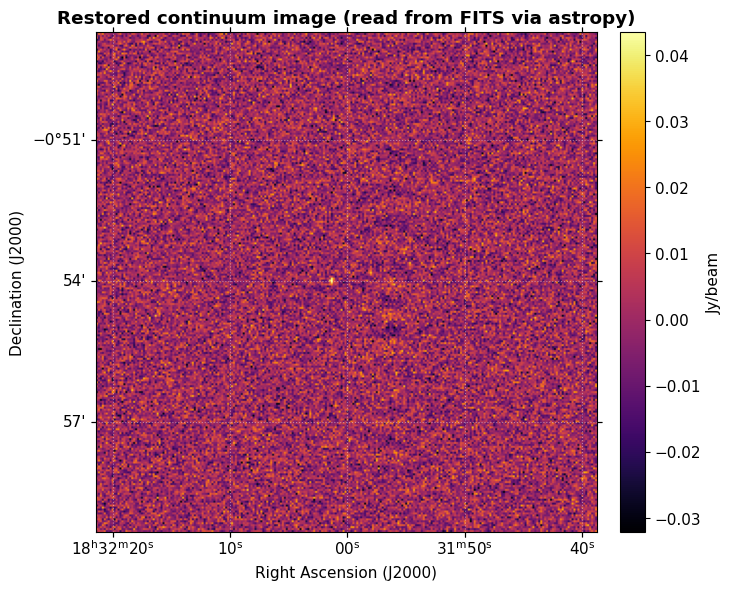

In [13]:
# Display the FITS image with its WCS so the axes are RA/Dec.
fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(111, projection=wcs)
im = ax.imshow(image, origin="lower", cmap="inferno")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=header.get("BUNIT", ""))
ax.set_xlabel("Right Ascension (J2000)")
ax.set_ylabel("Declination (J2000)")
ax.set_title("Restored continuum image (read from FITS via astropy)")
ax.grid(color="white", ls=":", alpha=0.4)
plt.show()

## Try it yourself

The first two run on the **base environment** with the simulation; the last two
are the real thing and **must be run in the CASA container** (launch it with
`podman compose -f containers/compose.yaml --profile interferometry up casa`).

1. **Weighting changes the beam.** In Chapter 8 you saw how $uv$ coverage sets
   the dirty beam. Down-weight the long baselines in `uv` (keep only samples
   with $\sqrt{u^2+v^2}$ below some cutoff) to mimic *natural-like* weighting,
   re-grid, and recompute `dirty_beam`. Compare the beam width and sidelobe
   level to the original. This is what `robust` does in `tclean`.

2. **Masking matters.** Re-run `hogbom_clean` with a much larger `n_iter` and
   `threshold=0.0` so it cleans into the noise. Watch spurious components appear
   away from the true sources — then add a simple box mask (zero the dirty image
   outside a region around the sources before cleaning) and see them vanish.
   This is why `tclean` uses `usemask='auto-multithresh'`.

3. **`# TODO` (container): make a real dirty image.** In the CASA container, run
   `tclean(..., niter=0)` on the calibrated MS to produce *just* the dirty image
   and PSF, then `exportfits` both and read them here with astropy. Compare the
   real PSF to our `dirty_beam`. Fill in the `tclean` call below.

4. **`# TODO` (container): one round of self-calibration.** After an initial
   `tclean`, run `gaincal` against the `MODEL_DATA` it wrote, `applycal` the
   solution, and re-image. Measure the change in image RMS (noise) and peak —
   the dynamic-range improvement is the whole point of self-cal.

In [14]:
# TODO (container only): make a real dirty image + PSF with tclean(niter=0).
# Run this inside the CASA container, then read the FITS back with astropy above.
if CASA_AVAILABLE:
    from casatasks import tclean, exportfits

    vis = "data/3C391_ctm_mosaic_10s_spw0.ms"

    # TODO: set niter=0 to stop after gridding (dirty image only, no CLEAN),
    #       choose imsize/cell, and export both the .image and .psf to FITS.
    tclean(
        vis=vis,
        field="3C391*",
        imagename="3C391_dirty",
        imsize=[480, 480],
        cell="2.5arcsec",
        weighting="briggs",
        robust=0.5,
        niter=0,            # TODO: keep 0 for a pure dirty image
        # TODO: deconvolver=..., gridder=...
    )
    # TODO: exportfits the .image and .psf, then load with astropy.io.fits.
    print("TODO: export and inspect the real dirty image + PSF.")
else:
    print("TODO exercise 3 requires the CASA container -- skipped on base env.")

TODO exercise 3 requires the CASA container -- skipped on base env.


In [15]:
# TODO (container only): one round of phase self-calibration.
if CASA_AVAILABLE:
    from casatasks import gaincal, applycal, tclean

    vis = "data/3C391_ctm_mosaic_10s_spw0.ms"

    # TODO: solve phase-only gains against the tclean model (MODEL_DATA),
    #       apply them, and re-image. Compare RMS/peak before vs after.
    gaincal(
        vis=vis,
        caltable="cal.selfcal_p1",
        field="3C391*",
        solint="30s",        # TODO: tune the solution interval
        refant="ea21",
        calmode="p",         # phase-only first; amplitude later if needed
        # TODO: gaintable=[...] from the original calibration
    )
    # TODO: applycal(...) then re-run tclean and measure the improvement.
    print("TODO: apply self-cal solution and re-image.")
else:
    print("TODO exercise 4 requires the CASA container -- skipped on base env.")

TODO exercise 4 requires the CASA container -- skipped on base env.


## Recap

- A **Measurement Set** is a relational database of visibilities: a `MAIN` table
  with one row per sample (`DATA`/`CORRECTED_DATA`, `UVW`, `WEIGHT`, `FLAG`,
  antenna and field indices) plus sub-tables for the array geometry, frequencies
  and fields.
- The **VLA continuum workflow** is *inspect & flag* → *set the flux scale*
  (`setjy`) → *calibrate* (`bandpass`, `gaincal`, `fluxscale`, `applycal`) →
  *image* (`tclean`) → optionally *self-calibrate* and re-image. Calibration is
  the measurement equation $V^{\mathrm{obs}}_{ij} = g_i g_j^* b_i b_j^*
  V^{\mathrm{true}}_{ij}$ solved on known calibrators.
- **`tclean`** is Chapter 9's Högbom CLEAN industrialised: a **minor cycle**
  (image-plane CLEAN, building a model) inside a **major cycle** (visibility-plane
  residual re-imaging), with **weighting** (natural/uniform/Briggs) controlling
  the dirty beam, **masks** keeping noise out of the model, and **self-cal**
  closing the loop on dynamic range.
- The output is a **FITS image** you read with `astropy.io.fits` and
  `astropy.wcs.WCS` — pixels, header, WCS, and restoring beam — the same skills
  from the single-dish chapters.
- Because CASA is heavy and version-pinned, it lives in a **container**; this
  notebook ran on the base environment by simulating every step and presenting
  the CASA code guarded behind `CASA_AVAILABLE`.

## What's next

You now have the full interferometry arc: an interferometer is a Fourier machine
(Ch 8), CLEAN deconvolves the dirty beam (Ch 9), and CASA's `tclean` scales that
up to real VLA data (this chapter). From here, the natural next steps in a real
project are **wide-field and mosaic imaging** (the $w$-term and primary-beam
mosaics), **spectral-line imaging** (image cubes channel by channel — the same
`tclean`, with `specmode='cube'`), and **polarimetry**. Each is a specialisation
of the same MS → calibrate → `tclean` → FITS pipeline you have now seen end to
end.